# Exploração — PM2.5 Tratado (2013-2019)

Análise exploratória da série tratada de qualidade do ar — **Estação Congonhas (id=08), São Paulo**.

| Ficheiro | Descrição |
|---|---|
| `pm25_treated.csv` | Gaps ≤ 3h → linear, 3-24h → spline, > 24h → NaN |
| `dados_pm25_estacao8_2013_2019.csv` | Série bruta CETESB (referência) |

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.style.use('dark_background')

AZUL     = '#64b5f6'
VERMELHO = '#ef5350'
VERDE    = '#66bb6a'
LARANJA  = '#ffa726'
ROXO     = '#ab47bc'
CINZA    = '#90a4ae'
ROSA     = '#f48fb1'

MESES_PT = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

## Carregamento dos dados

In [ ]:

df = pd.read_csv('../processed_data/pm25_treated.csv', index_col=0)
df.index = pd.to_datetime(df.index, utc=True)

cetesb_raw = pd.read_csv('../processed_data/dados_pm25_estacao8_2013_2019.csv')
cetesb_raw['time'] = (
    pd.to_datetime(cetesb_raw['time'])
    .dt.tz_localize('Etc/GMT+3')
    .dt.tz_convert('UTC')
)
cetesb_raw = cetesb_raw.set_index('time').sort_index()
raw = cetesb_raw[['MP2.5']].reindex(df.index)   # mesmo índice que o tratado

n_nan_t = df['MP2.5'].isna().sum()
pct_t   = df['MP2.5'].isna().mean() * 100
n_nan_r = raw['MP2.5'].isna().sum()
pct_r   = raw['MP2.5'].isna().mean() * 100

print(f'Tratado  — {df.shape[0]} linhas | {df.index.min().date()} → {df.index.max().date()}')
print(f'NaN PM2.5 tratado : {n_nan_t} ({pct_t:.2f}%)')
print(f'NaN PM2.5 bruto   : {n_nan_r} ({pct_r:.2f}%)')
df.head(3)

Tratado  — 55008 linhas | 2013-05-09 → 2019-08-18
NaN PM2.5 tratado : 2826 (5.14%)
NaN PM2.5 bruto   : 3332 (6.06%)


,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
2013-05-09 03:00:00+00:00,26.0,10.301001,91.64832,0.0,7.421590
2013-05-09 04:00:00+00:00,21.0,9.751000,92.54831,0.0,7.993298
2013-05-09 05:00:00+00:00,20.0,9.401000,92.52839,0.0,7.928178


In [4]:
def blocos_nan(series):
    '''Devolve lista de (inicio, fim, duracao_h) para cada bloco NaN.'''
    vals = series.isna().values
    blocos = []
    i = 0
    while i < len(vals):
        if vals[i]:
            j = i
            while j < len(vals) and vals[j]:
                j += 1
            blocos.append((series.index[i], series.index[j - 1], j - i))
            i = j
        else:
            i += 1
    return blocos

## 1. Série Temporal Completa de PM2.5 (2013-2019)

Os **blocos a vermelho** são gaps > 24h mantidos como NaN.

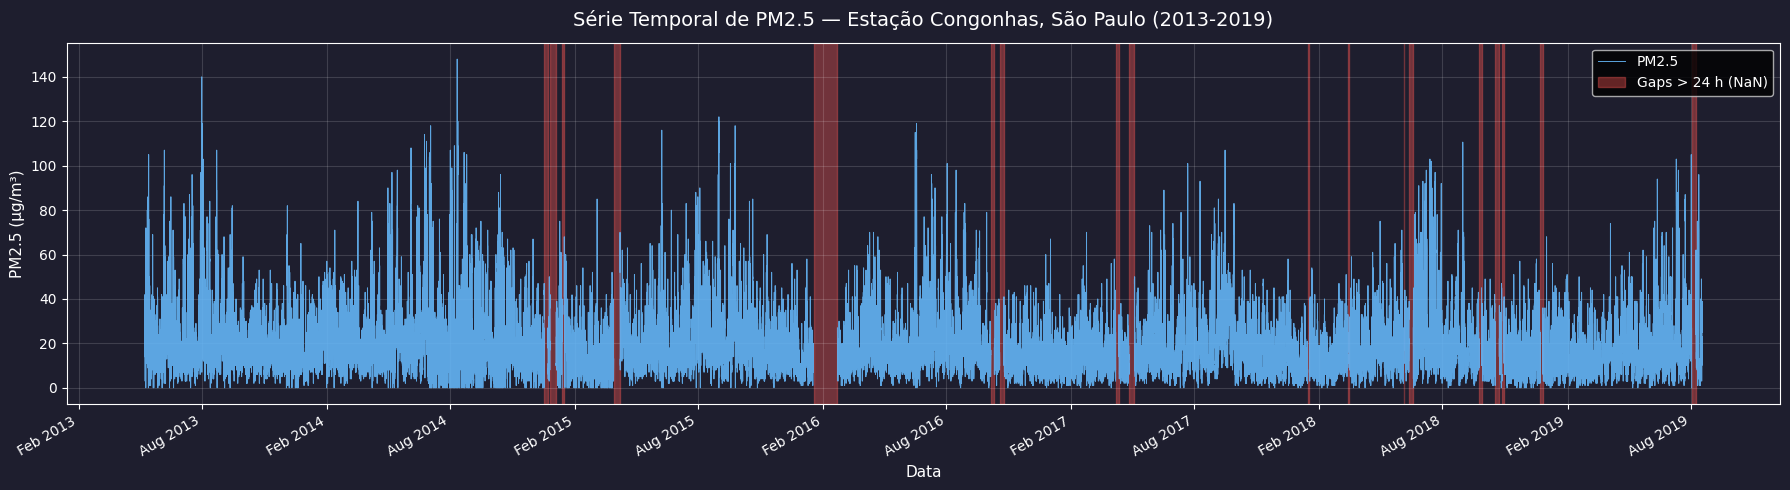

In [5]:
fig, ax = plt.subplots(figsize=(18, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

ax.plot(df.index, df['MP2.5'], color=AZUL, linewidth=0.7, alpha=0.9, label='PM2.5')

primeiro = True
for inicio, fim, dur in blocos_nan(df['MP2.5']):
    if dur > 24:
        lbl = 'Gaps > 24 h (NaN)' if primeiro else ''
        ax.axvspan(inicio, fim, color=VERMELHO, alpha=0.40, label=lbl)
        primeiro = False

ax.set_title('Série Temporal de PM2.5 — Estação Congonhas, São Paulo (2013-2019)',
             fontsize=14, pad=12)
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=11)
ax.set_xlabel('Data', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

## 2. Antes vs Depois do Tratamento

- **Painel superior**: série bruta (lacunas visíveis onde a linha quebra).
- **Painel inferior**: série tratada — pontos interpolados a **laranja**, gaps > 24 h a vermelho.
- **Zoom**: região do maior gap tratado por spline.

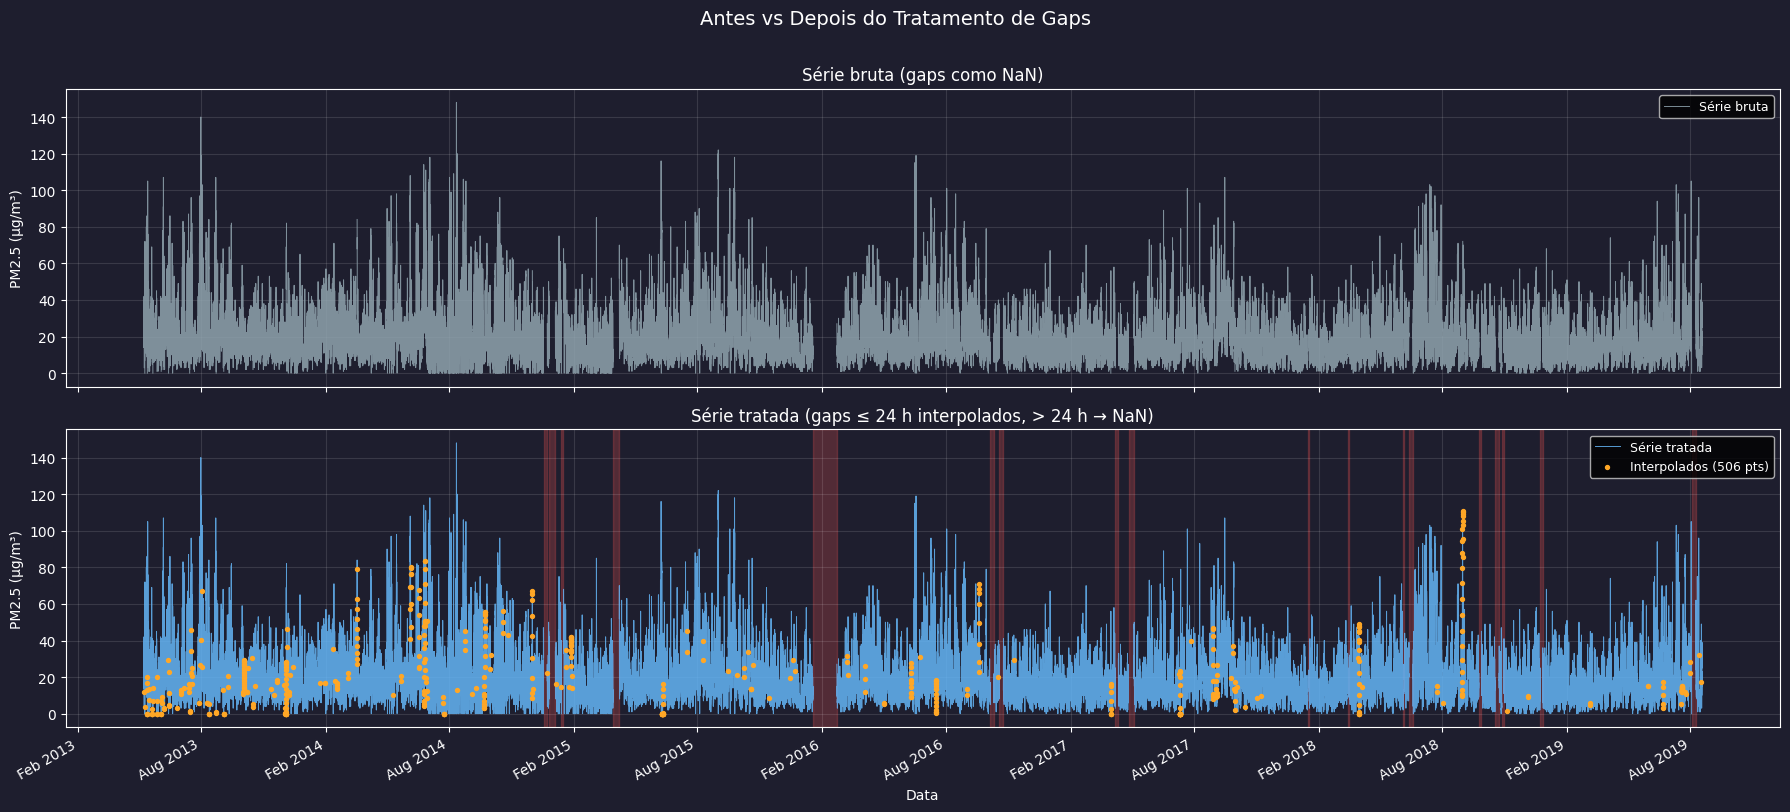

In [6]:
# máscara: NaN no bruto, preenchido no tratado
interp_mask = raw['MP2.5'].isna() & df['MP2.5'].notna()

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
fig.patch.set_facecolor('#1e1e2e')
for ax in axes:
    ax.set_facecolor('#1e1e2e')

# painel superior: bruto
axes[0].plot(raw.index, raw['MP2.5'], color=CINZA, linewidth=0.7, alpha=0.85, label='Série bruta')
axes[0].set_title('Série bruta (gaps como NaN)', fontsize=12)
axes[0].set_ylabel('PM2.5 (µg/m³)', fontsize=10)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.12)

# painel inferior: tratado
axes[1].plot(df.index, df['MP2.5'], color=AZUL, linewidth=0.7, alpha=0.85, label='Série tratada')
axes[1].scatter(
    df[interp_mask].index, df.loc[interp_mask, 'MP2.5'],
    color=LARANJA, s=8, zorder=5, label=f'Interpolados ({interp_mask.sum()} pts)',
)
for inicio, fim, dur in blocos_nan(df['MP2.5']):
    if dur > 24:
        axes[1].axvspan(inicio, fim, color=VERMELHO, alpha=0.25)
axes[1].set_title('Série tratada (gaps ≤ 24 h interpolados, > 24 h → NaN)', fontsize=12)
axes[1].set_ylabel('PM2.5 (µg/m³)', fontsize=10)
axes[1].set_xlabel('Data', fontsize=10)
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.12)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right')
plt.suptitle('Antes vs Depois do Tratamento de Gaps', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

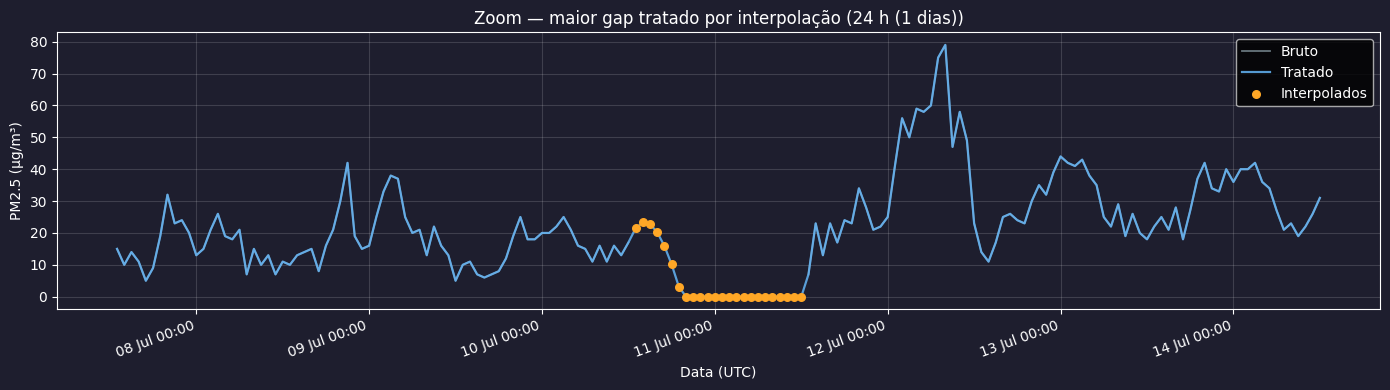

In [ ]:

vals_im = interp_mask.values
max_dur, best_start, best_end = 0, 0, 0
i = 0
while i < len(vals_im):
    if vals_im[i]:
        j = i
        while j < len(vals_im) and vals_im[j]:
            j += 1
        if j - i > max_dur:
            max_dur, best_start, best_end = j - i, i, j
        i = j
    else:
        i += 1

if max_dur > 0:
    margin = pd.Timedelta(hours=max(72, max_dur * 3))
    t0 = df.index[best_start] - margin
    t1 = df.index[best_end - 1] + margin

    fig, ax = plt.subplots(figsize=(14, 4))
    fig.patch.set_facecolor('#1e1e2e')
    ax.set_facecolor('#1e1e2e')

    zr = raw.loc[t0:t1, 'MP2.5']
    zt = df.loc[t0:t1, 'MP2.5']
    zi = interp_mask.loc[t0:t1]

    ax.plot(zr.index, zr, color=CINZA, linewidth=1.3, alpha=0.7, label='Bruto')
    ax.plot(zt.index, zt, color=AZUL, linewidth=1.6, alpha=0.85, label='Tratado')
    ax.scatter(zt[zi].index, zt[zi], color=LARANJA, s=30, zorder=6, label='Interpolados')

    dur_label = f'{max_dur} h ({max_dur/24:.0f} dias)' if max_dur >= 24 else f'{max_dur} h'
    ax.set_title(f'Zoom — maior gap tratado por interpolação ({dur_label})', fontsize=12)
    ax.set_ylabel('PM2.5 (µg/m³)', fontsize=10)
    ax.set_xlabel('Data (UTC)', fontsize=10)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.15)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

## 3. Distribuição de PM2.5

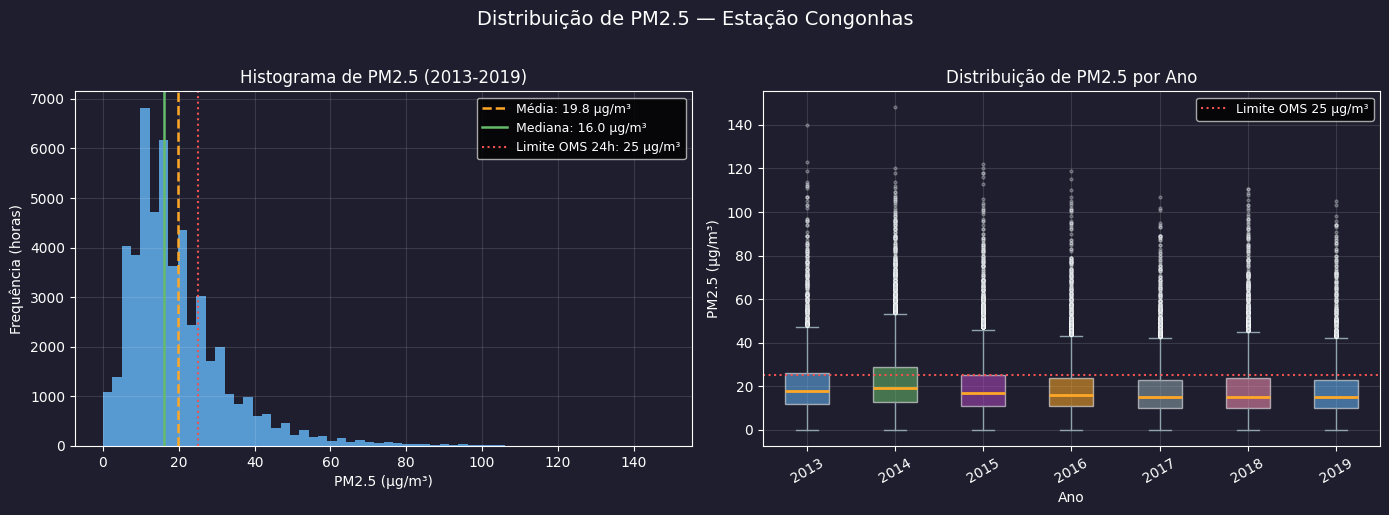

count    52182.00
mean        19.76
std         13.82
min          0.00
25%         11.00
50%         16.00
75%         25.00
max        148.00

Acima do limite OMS (25 µg/m³): 24.3% das horas


In [ ]:
pm25v = df['MP2.5'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1e1e2e')
for ax in axes:
    ax.set_facecolor('#1e1e2e')

axes[0].hist(pm25v, bins=60, color=AZUL, alpha=0.82, edgecolor='none')
axes[0].axvline(pm25v.mean(),   color=LARANJA, lw=1.8, ls='--', label=f'Média: {pm25v.mean():.1f} µg/m³')
axes[0].axvline(pm25v.median(), color=VERDE,   lw=1.8, ls='-',  label=f'Mediana: {pm25v.median():.1f} µg/m³')
axes[0].axvline(25, color=VERMELHO, lw=1.5, ls=':', label='Limite OMS 24h: 25 µg/m³')
axes[0].set_title('Histograma de PM2.5 (2013-2019)', fontsize=12)
axes[0].set_xlabel('PM2.5 (µg/m³)', fontsize=10)
axes[0].set_ylabel('Frequência (horas)', fontsize=10)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.12)


anos = sorted(df.index.year.unique())
dados_ano = [df.loc[df.index.year == a, 'MP2.5'].dropna().values for a in anos]
paleta = [AZUL, VERDE, ROXO, LARANJA, CINZA, ROSA, AZUL]  # 7 anos
cores_bp = paleta[:len(anos)]

bp = axes[1].boxplot(
    dados_ano, labels=anos, patch_artist=True,
    medianprops=dict(color=LARANJA, linewidth=2),
    whiskerprops=dict(color=CINZA), capprops=dict(color=CINZA),
    flierprops=dict(marker='o', markerfacecolor=CINZA, markersize=2, alpha=0.3, linestyle='none'),
)
for patch, cor in zip(bp['boxes'], cores_bp):
    patch.set_facecolor(cor); patch.set_alpha(0.55)

axes[1].axhline(25, color=VERMELHO, lw=1.5, ls=':', label='Limite OMS 25 µg/m³')
axes[1].set_title('Distribuição de PM2.5 por Ano', fontsize=12)
axes[1].set_xlabel('Ano', fontsize=10)
axes[1].set_ylabel('PM2.5 (µg/m³)', fontsize=10)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.12)

plt.suptitle('Distribuição de PM2.5 — Estação Congonhas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(pm25v.describe().round(2).to_string())
pct_oms = (pm25v > 25).mean() * 100
print(f'\nAcima do limite OMS (25 µg/m³): {pct_oms:.1f}% das horas')

## 4. Sazonalidade — Heatmap Hora do Dia × Mês do Ano

Média de PM2.5 por hora local e mês, revelando padrões diários e sazonais.

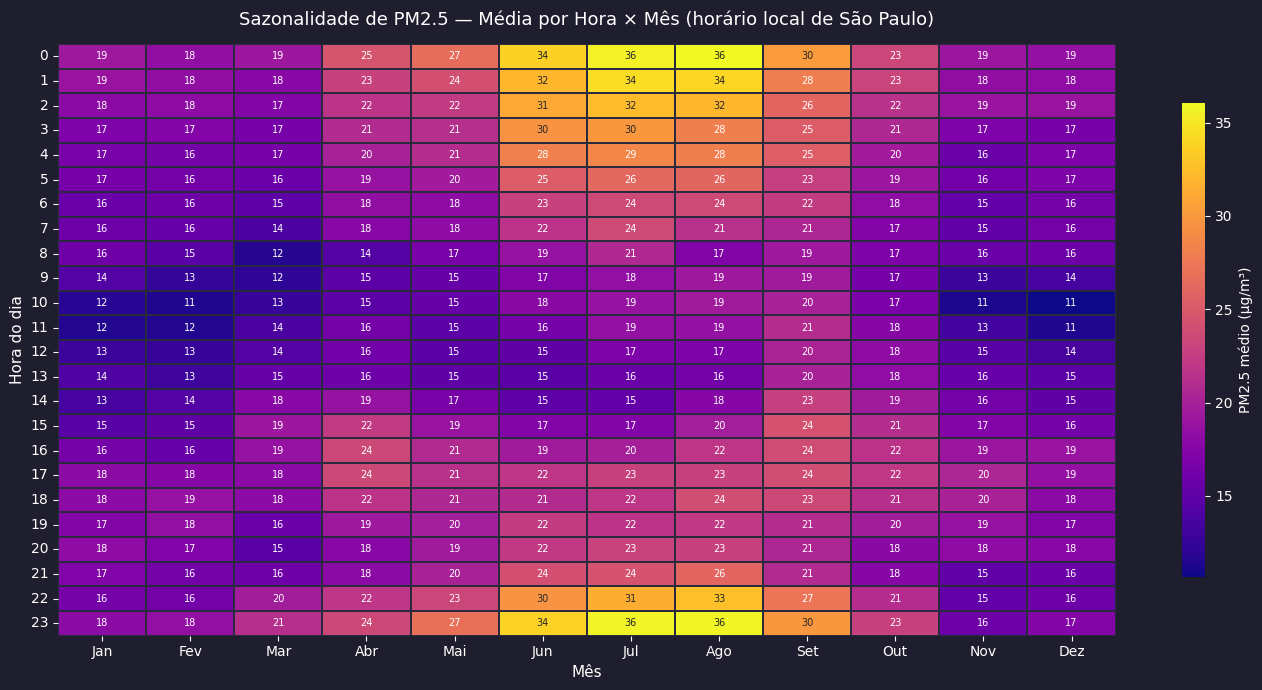

In [9]:
df_sp = df[['MP2.5']].copy()
df_sp.index = df_sp.index.tz_convert('America/Sao_Paulo')
df_sp['hora'] = df_sp.index.hour
df_sp['mes']  = df_sp.index.month

pivot = (
    df_sp.groupby(['hora', 'mes'])['MP2.5']
    .mean()
    .unstack('mes')
)
pivot.columns = MESES_PT

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

sns.heatmap(
    pivot, ax=ax,
    cmap='plasma',
    linewidths=0.3,
    linecolor='#2a2a3e',
    annot=True, fmt='.0f', annot_kws={'size': 7},
    cbar_kws={'label': 'PM2.5 médio (µg/m³)', 'shrink': 0.8},
)
ax.set_title(
    'Sazonalidade de PM2.5 — Média por Hora × Mês (horário local de São Paulo)',
    fontsize=13, pad=14,
)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Hora do dia', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 5. Série Temporal das 5 Variáveis

PM2.5, temperatura, humidade relativa, precipitação e velocidade do vento.
Os fundos a vermelho indicam os gaps > 24h do PM2.5.

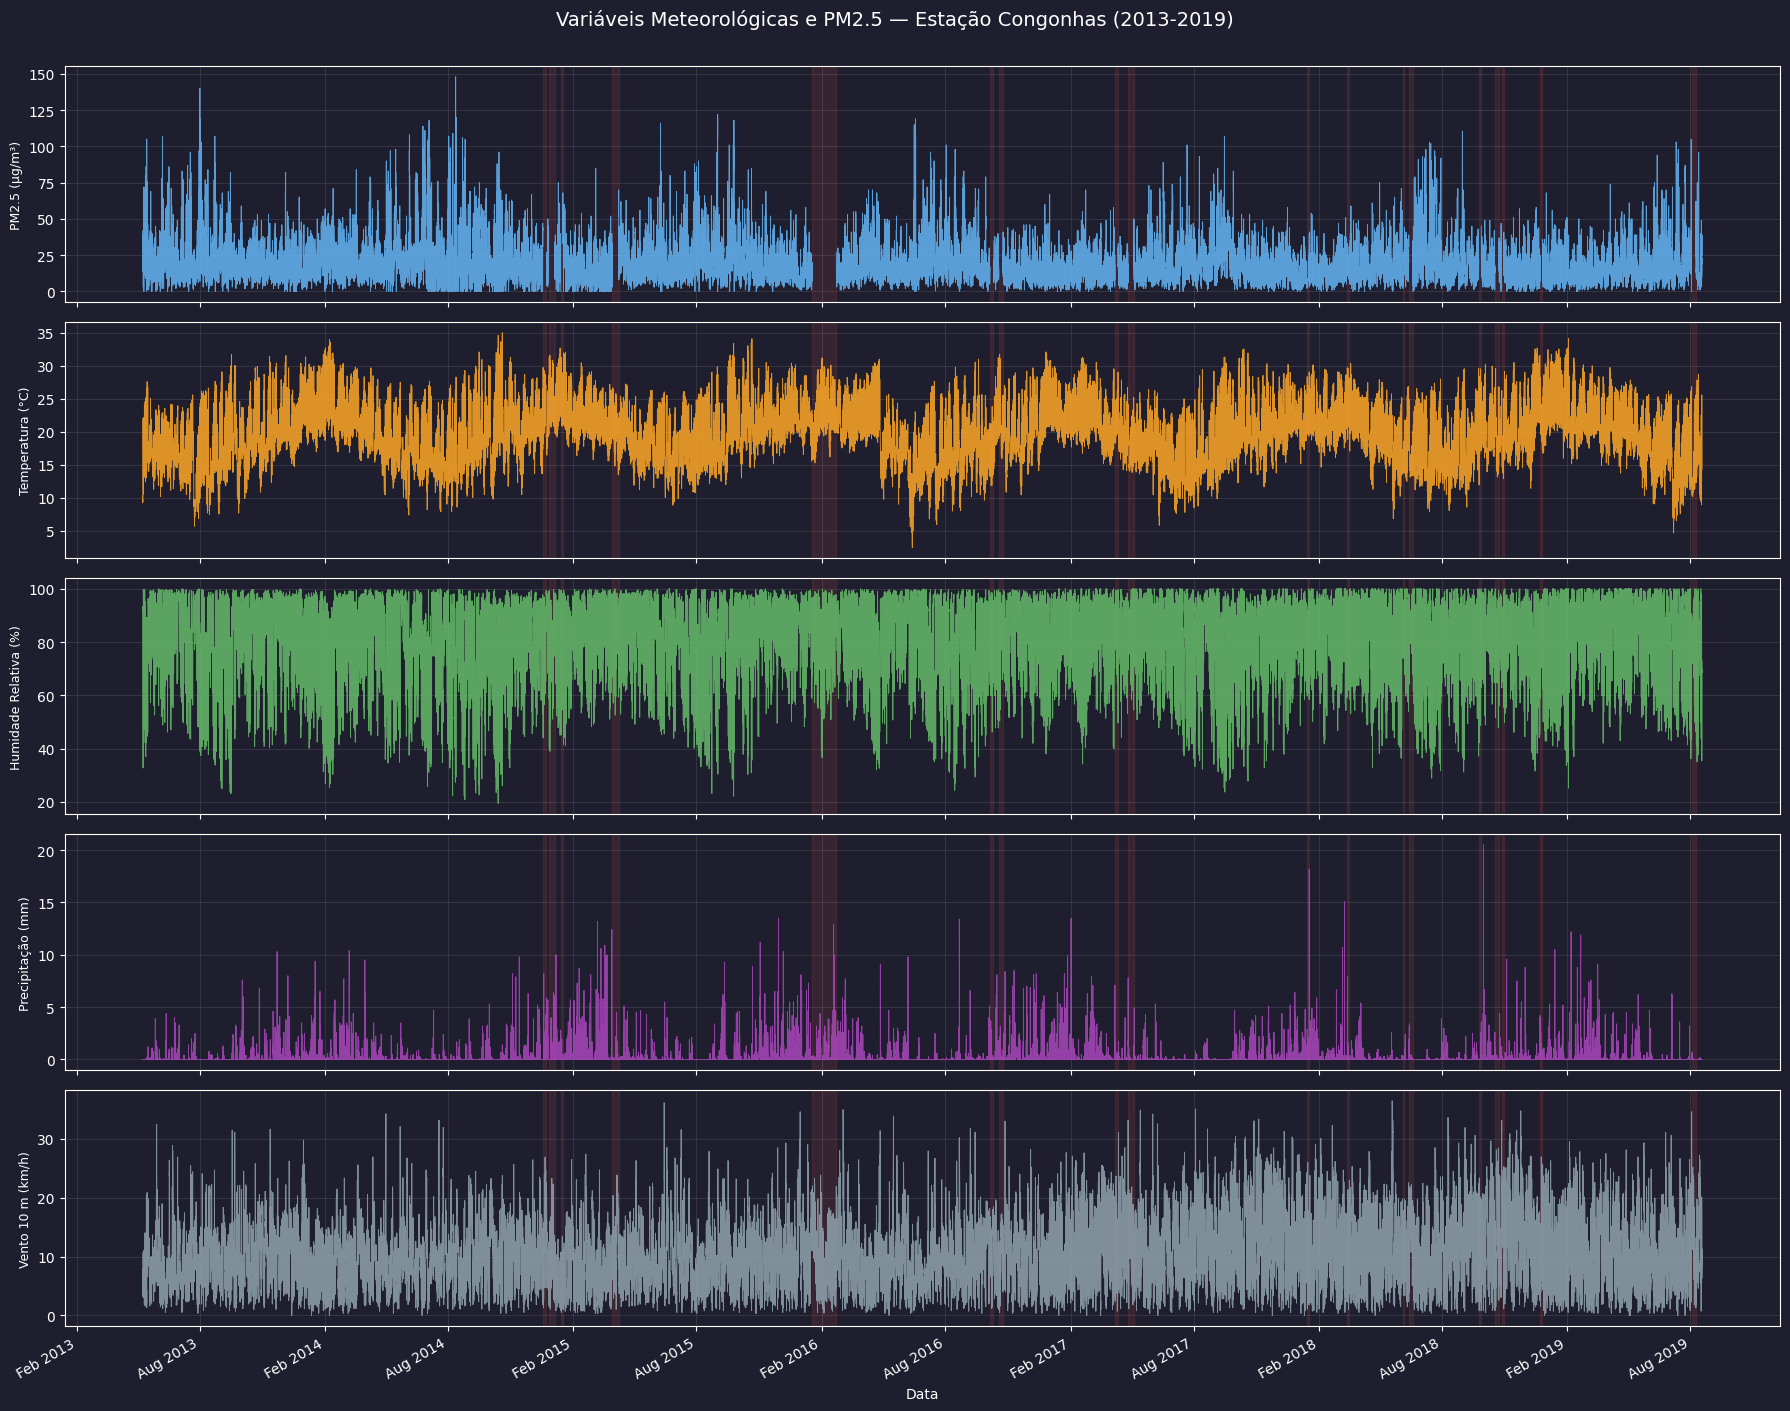

In [10]:
VARS = [
    ('MP2.5',                'PM2.5 (µg/m³)',        AZUL),
    ('temperature_2m',       'Temperatura (°C)',      LARANJA),
    ('relative_humidity_2m', 'Humidade Relativa (%)', VERDE),
    ('precipitation',        'Precipitação (mm)',     ROXO),
    ('wind_speed_10m',       'Vento 10 m (km/h)',     CINZA),
]

gaps_grandes = [(i, f, d) for i, f, d in blocos_nan(df['MP2.5']) if d > 24]

fig, axes = plt.subplots(len(VARS), 1, figsize=(18, 14), sharex=True)
fig.patch.set_facecolor('#1e1e2e')

for ax, (col, label, cor) in zip(axes, VARS):
    ax.set_facecolor('#1e1e2e')
    ax.plot(df.index, df[col], color=cor, linewidth=0.65, alpha=0.85)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.10)
    for inicio, fim, _ in gaps_grandes:
        ax.axvspan(inicio, fim, color=VERMELHO, alpha=0.12)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right')
axes[-1].set_xlabel('Data', fontsize=10)

fig.suptitle(
    'Variáveis Meteorológicas e PM2.5 — Estação Congonhas (2013-2019)',
    fontsize=14, y=1.005,
)
plt.tight_layout()
plt.show()